# Fall Detection — MobileNetV3 One-Step Detector

A **fall-detection focused** single-step CNN detector built on a MobileNetV3-Small backbone.

### Key Design Decisions vs Previous Version
| Decision | Previous | This Version | Reason |
|---|---|---|---|
| Loss weighting | coord×5, class×1 | coord×2, class×4 | Prioritise *what* over *where* |
| Fall class weight | equal | ×3 upweighted | Falls are rare — prevent majority-class bias |
| Backbone | Custom CNN / ResNet | MobileNetV3-Small only | Fast on CPU, ImageNet pretrained |
| Evaluation | Basic loss | mAP@0.5, mAP@0.5:0.95, mean IoU, confusion matrix | Full detection metrics |

### Architecture
```
Input [3, 224, 224]
  └─► MobileNetV3-Small backbone  (ImageNet pretrained, 576 output channels)
        └─► AdaptiveAvgPool → [576, 7, 7]
              └─► Detection Head (conv layers)
                    └─► [7, 7, B*5 + C]  =  [7, 7, 13]
                          ├─ Box 1: cx, cy, w, h, objectness
                          ├─ Box 2: cx, cy, w, h, objectness
                          └─ Classes: P(fall) P(walk) P(sit)
```

### Classes
**0** = fall_detected | **1** = walk | **2** = sit

## 0. Imports & Configuration

In [1]:
import os, random, shutil, time, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.transforms import functional as TF
from torchvision import models

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR  = Path('../dataset/fall_dataset')
IMG_DIR   = BASE_DIR / 'images'
LABEL_DIR = BASE_DIR / 'labels'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device      : {DEVICE}')
print(f'Platform    : {platform.system()}')

# ── Grid & image hyperparameters ─────────────────────────────────────────────
S           = 7
B           = 2
NUM_CLASSES = 3
IMG_SIZE    = 224 if not torch.cuda.is_available() else 448

# ── Class definitions ────────────────────────────────────────────────────────
CLASS_NAMES   = ['fall_detected', 'walk', 'sit']
CLASS_TO_IDX  = {name: i for i, name in enumerate(CLASS_NAMES)}

# ── Fall-focused class weights ───────────────────────────────────────────────
# fall_detected gets 3× weight so the model is penalised harder for missing falls
CLASS_WEIGHTS = torch.tensor([3.0, 1.0, 1.0]).to(DEVICE)

# ── DataLoader config ────────────────────────────────────────────────────────
IS_WINDOWS  = platform.system() == 'Windows'
NUM_WORKERS = 0 if IS_WINDOWS else 2
PIN_MEMORY  = torch.cuda.is_available()

print(f'IMG_SIZE    : {IMG_SIZE}')
print(f'Grid        : {S}×{S}  |  Boxes/cell: {B}  |  Classes: {NUM_CLASSES}')
print(f'num_workers : {NUM_WORKERS}  |  pin_memory: {PIN_MEMORY}')
print(f'Class weights (fall / walk / sit): {CLASS_WEIGHTS.tolist()}')

Device      : cpu
Platform    : Windows
IMG_SIZE    : 224
Grid        : 7×7  |  Boxes/cell: 2  |  Classes: 3
num_workers : 0  |  pin_memory: False
Class weights (fall / walk / sit): [3.0, 1.0, 1.0]


## 1. Merge val → train & Dataset Audit

In [2]:
# ── Merge val into train ─────────────────────────────────────────────────────
for folder in ['images', 'labels']:
    src = BASE_DIR / folder / 'val'
    dst = BASE_DIR / folder / 'train'
    dst.mkdir(parents=True, exist_ok=True)
    for f in src.iterdir():
        dest = dst / f.name
        if not dest.exists():
            shutil.copy(f, dest)
print('Val merged into train.')

# ── Audit: class distribution & multi-person images ─────────────────────────
def audit_labels(split):
    label_path = LABEL_DIR / split
    class_counts   = Counter()
    persons_counts = Counter()
    cell_collisions = 0

    for txt in sorted(label_path.glob('*.txt')):
        lines = [l.strip() for l in open(txt) if l.strip()]
        persons_counts[len(lines)] += 1
        cells = []
        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue
            cls = int(parts[0])
            class_counts[cls] += 1
            cx, cy = float(parts[1]), float(parts[2])
            cells.append((int(cx * S), int(cy * S)))
        if len(cells) != len(set(cells)):
            cell_collisions += 1

    print(f'\n[{split}]')
    print(f'  Total images : {sum(persons_counts.values())}')
    print(f'  Class counts : { {CLASS_NAMES[k]: v for k,v in sorted(class_counts.items())} }')
    print(f'  Persons/image: { dict(sorted(persons_counts.items())) }')
    print(f'  Cell collisions (objects sharing same grid cell): {cell_collisions}')
    return class_counts

train_counts = audit_labels('train')
val_counts   = audit_labels('val')

Val merged into train.

[train]
  Total images : 538
  Class counts : {'fall_detected': 271, 'walk': 320, 'sit': 255}
  Persons/image: {1: 407, 2: 55, 3: 36, 4: 18, 5: 7, 6: 7, 7: 2, 8: 1, 9: 3, 11: 1, 15: 1}
  Cell collisions (objects sharing same grid cell): 17

[val]
  Total images : 111
  Class counts : {'fall_detected': 72, 'walk': 23, 'sit': 19}
  Persons/image: {1: 108, 2: 3}
  Cell collisions (objects sharing same grid cell): 0


## 2. Preprocessing — Letterbox Resize

Preserves aspect ratio by padding instead of squishing — critical for fall detection
because a fallen person's wide/flat aspect ratio is a primary visual cue.

In [3]:
class LetterboxResize:
    """
    Resize to (size × size) while preserving aspect ratio.
    Pads with value 114 (standard YOLO neutral grey).
    Distortion-free — a fallen person (wide) stays wide,
    a standing person (tall) stays tall.
    """
    def __init__(self, size: int):
        self.size = size

    def __call__(self, img: Image.Image) -> Image.Image:
        W, H   = img.size
        scale  = self.size / max(W, H)
        new_W  = int(W * scale)
        new_H  = int(H * scale)
        img    = TF.resize(img, (new_H, new_W))

        pad_left   = (self.size - new_W) // 2
        pad_top    = (self.size - new_H) // 2
        pad_right  = self.size - new_W - pad_left
        pad_bottom = self.size - new_H - pad_top

        return TF.pad(img, (pad_left, pad_top, pad_right, pad_bottom), fill=114)

## 3. Dataset

In [4]:
class FallDetectionDataset(Dataset):
    """
    Loads images + YOLO-format labels and converts them to
    an [S, S, B*5 + C] detection target tensor.

    Fall-focused changes vs previous version:
    - LetterboxResize instead of T.Resize (no aspect ratio distortion)
    - Augmentation preserves spatial geometry (no aggressive random crops
      that could cut out the fallen person)
    """
    def __init__(self, split: str, img_size: int = 224,
                 S: int = 7, B: int = 2, C: int = 3,
                 augment: bool = False):
        self.img_dir   = IMG_DIR / split
        self.label_dir = LABEL_DIR / split
        self.img_size  = img_size
        self.S, self.B, self.C = S, B, C
        self.augment   = augment

        self.img_files = sorted(
            list(self.img_dir.glob('*.jpg')) +
            list(self.img_dir.glob('*.png'))
        )

        self.normalize = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
        # Base: letterbox only — no distortion
        self.base_transform = T.Compose([
            LetterboxResize(img_size),
            T.ToTensor(),
        ])
        # Augmentation: gentle — preserve body shape & fall posture
        # No random crops (could remove the fallen person entirely)
        self.aug_transform = T.Compose([
            LetterboxResize(img_size),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.3, contrast=0.3,
                          saturation=0.2, hue=0.05),
            T.RandomGrayscale(p=0.05),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.img_files)

    def get_label(self, idx):
        """Return raw label list for image idx — used by sampler."""
        txt = self.label_dir / (self.img_files[idx].stem + '.txt')
        classes = []
        if txt.exists():
            for line in open(txt):
                parts = line.strip().split()
                if len(parts) >= 5:
                    classes.append(int(parts[0]))
        return classes

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        img      = Image.open(img_path).convert('RGB')

        if self.augment:
            img_tensor = self.aug_transform(img)
        else:
            img_tensor = self.base_transform(img)

        img_tensor = self.normalize(img_tensor)

        # ── Build [S, S, B*5 + C] target ────────────────────────────────────
        target   = torch.zeros(self.S, self.S, self.B * 5 + self.C)
        txt_path = self.label_dir / (img_path.stem + '.txt')

        if txt_path.exists():
            with open(txt_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id         = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])

                    col = min(int(cx * self.S), self.S - 1)
                    row = min(int(cy * self.S), self.S - 1)
                    cx_cell = cx * self.S - col
                    cy_cell = cy * self.S - row

                    if target[row, col, 4] == 0:   # cell not yet occupied
                        for b in range(self.B):
                            target[row, col, b*5 + 0] = cx_cell
                            target[row, col, b*5 + 1] = cy_cell
                            target[row, col, b*5 + 2] = bw
                            target[row, col, b*5 + 3] = bh
                            target[row, col, b*5 + 4] = 1.0
                        target[row, col, self.B * 5 + cls_id] = 1.0

        return img_tensor, target


# ── Datasets ─────────────────────────────────────────────────────────────────
train_dataset = FallDetectionDataset('train', IMG_SIZE, S, B, NUM_CLASSES, augment=True)
val_dataset   = FallDetectionDataset('val',   IMG_SIZE, S, B, NUM_CLASSES, augment=False)
print(f'Train: {len(train_dataset)} images  |  Val: {len(val_dataset)} images')

Train: 559 images  |  Val: 111 images


In [5]:
# ── Weighted sampler — oversample fall images ─────────────────────────────────
# Count how many falls, walks, sits each training image contains.
# Images containing a fall get higher sampling probability so the model
# sees proportionally more fall examples per epoch.

def make_fall_weighted_sampler(dataset):
    sample_weights = []
    for i in range(len(dataset)):
        labels = dataset.get_label(i)
        # If image contains at least one fall → weight 3.0, else 1.0
        w = 3.0 if (0 in labels) else 1.0
        sample_weights.append(w)
    return WeightedRandomSampler(
        weights     = sample_weights,
        num_samples = len(sample_weights),
        replacement = True
    )

sampler = make_fall_weighted_sampler(train_dataset)

train_loader = DataLoader(train_dataset, batch_size=8, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=False)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print('Weighted sampler active — fall images oversampled 3×')

Train batches : 70
Val batches   : 14
Weighted sampler active — fall images oversampled 3×


## 4. Model — MobileNetV3 + Detection Head

In [6]:
class MobileNetBackbone(nn.Module):
    """
    MobileNetV3-Small pretrained on ImageNet.
    Output: [B, 576, 7, 7] for 224×224 input.
    Classifier head removed — replaced by detection head.
    """
    def __init__(self, freeze_early: bool = True):
        super().__init__()
        mobilenet    = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )
        self.features = mobilenet.features   # 13 blocks, output 576 ch

        if freeze_early:
            for i, block in enumerate(self.features):
                if i < 4:   # freeze first 4 blocks (generic edge/texture features)
                    for param in block.parameters():
                        param.requires_grad = False

    def forward(self, x):
        return self.features(x)   # [B, 576, 7, 7]


class DetectionHead(nn.Module):
    """
    Conv-based detection head.
    Maps [B, 576, S, S] → [B, S, S, B*5 + C].
    Uses conv layers (not FC) to retain spatial structure.
    """
    def __init__(self, in_channels=576, S=7, B=2, C=3):
        super().__init__()
        out_ch = B * 5 + C   # 13
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.3),

            nn.Conv2d(512, 256, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv2d(256, out_ch, 1),
        )
        self.S = S

    def forward(self, x):
        return self.head(x).permute(0, 2, 3, 1)   # [B, S, S, 13]


class FallDetector(nn.Module):
    """Full one-step fall detector: MobileNetV3 backbone + detection head."""
    def __init__(self, S=7, B=2, C=3, freeze_early=True):
        super().__init__()
        self.backbone = MobileNetBackbone(freeze_early=freeze_early)
        self.pool     = nn.AdaptiveAvgPool2d((S, S))
        self.head     = DetectionHead(in_channels=576, S=S, B=B, C=C)

    def forward(self, x):
        f = self.backbone(x)    # [B, 576, 7, 7]
        f = self.pool(f)        # [B, 576, S, S]
        return self.head(f)     # [B, S, S, 13]


# Sanity check
model  = FallDetector(S=S, B=B, C=NUM_CLASSES)
dummy  = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
with torch.no_grad():
    out = model(dummy)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f'Output shape      : {out.shape}')        # [2, 7, 7, 13]
print(f'Total params      : {n_params:.2f}M')
print(f'Trainable params  : {n_train:.2f}M')
del dummy, out

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\fredb/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 40.0MB/s]


Output shape      : torch.Size([2, 7, 7, 13])
Total params      : 4.31M
Trainable params  : 4.30M


## 5. Fall-Focused Detection Loss

Key differences from the previous loss:

| Parameter | Previous | Now | Effect |
|---|---|---|---|
| `lambda_coord` | 5.0 | 2.0 | Less emphasis on where |
| `lambda_class` | 1.0 | 4.0 | More emphasis on what action |
| `lambda_noobj` | 0.5→2.0 | 2.0 | Keep false positives suppressed |
| Class weights | equal | fall×3 | Harder penalty for missing falls |

In [7]:
class FallFocusedLoss(nn.Module):
    """
    Detection loss tuned for fall detection:
      - lambda_coord lowered  → less fixation on bounding box precision
      - lambda_class raised   → stronger signal for action classification
      - class_weights applied → fall class penalised 3× harder when missed
    """
    def __init__(self, S=7, B=2, C=3,
                 lambda_coord=2.0,
                 lambda_noobj=2.0,
                 lambda_class=4.0,
                 class_weights=None):
        super().__init__()
        self.S             = S
        self.B             = B
        self.C             = C
        self.lambda_coord  = lambda_coord
        self.lambda_noobj  = lambda_noobj
        self.lambda_class  = lambda_class
        # class_weights: tensor [C] — upweights fall class in BCE
        self.register_buffer('class_weights',
                              class_weights if class_weights is not None
                              else torch.ones(C))

    def iou(self, boxes1, boxes2):
        """IoU for [..., 4] tensors in cx,cy,w,h format."""
        b1x1 = boxes1[..., 0] - boxes1[..., 2] / 2
        b1y1 = boxes1[..., 1] - boxes1[..., 3] / 2
        b1x2 = boxes1[..., 0] + boxes1[..., 2] / 2
        b1y2 = boxes1[..., 1] + boxes1[..., 3] / 2
        b2x1 = boxes2[..., 0] - boxes2[..., 2] / 2
        b2y1 = boxes2[..., 1] - boxes2[..., 3] / 2
        b2x2 = boxes2[..., 0] + boxes2[..., 2] / 2
        b2y2 = boxes2[..., 1] + boxes2[..., 3] / 2
        inter = ((torch.min(b1x2, b2x2) - torch.max(b1x1, b2x1)).clamp(0) *
                 (torch.min(b1y2, b2y2) - torch.max(b1y1, b2y1)).clamp(0))
        union = (boxes1[..., 2] * boxes1[..., 3] +
                 boxes2[..., 2] * boxes2[..., 3] - inter + 1e-6)
        return inter / union

    def forward(self, pred, target):
        batch      = pred.shape[0]
        obj_mask   = target[..., 4]        # [batch, S, S]
        noobj_mask = 1 - obj_mask

        # ── Responsible box selection (highest IoU with GT) ──────────────────
        ious = torch.stack([
            self.iou(pred[..., b*5:b*5+4], target[..., 0:4])
            for b in range(self.B)
        ], dim=-1)                         # [batch, S, S, B]
        best_box = ious.argmax(-1)         # [batch, S, S]

        # ── Coordinate loss ──────────────────────────────────────────────────
        coord_loss = 0
        for b in range(self.B):
            resp = (best_box == b).float() * obj_mask
            pred_xy = pred[..., b*5   : b*5+2]
            pred_wh = pred[..., b*5+2 : b*5+4]
            gt_xy   = target[..., 0:2]
            gt_wh   = target[..., 2:4]
            coord_loss += (resp.unsqueeze(-1) * (pred_xy - gt_xy).pow(2)).sum()
            # sqrt clamp BEFORE sqrt — prevents nan from negative predictions
            coord_loss += (resp.unsqueeze(-1) * (
                pred_wh.clamp(min=1e-6).sqrt() - gt_wh.clamp(min=1e-6).sqrt()
            ).pow(2)).sum()

        # ── Objectness loss ──────────────────────────────────────────────────
        obj_loss   = 0
        noobj_loss = 0
        for b in range(self.B):
            conf = pred[..., b*5+4]
            obj_loss   += (obj_mask   * (conf - 1).pow(2)).sum()
            noobj_loss += (noobj_mask * (conf - 0).pow(2)).sum()

        # ── Class loss with per-class weights ────────────────────────────────
        pred_cls = pred[..., self.B*5:]      # [batch, S, S, C]
        gt_cls   = target[..., self.B*5:]
        # weighted BCE — fall class (index 0) contributes 3× more to loss
        bce = F.binary_cross_entropy_with_logits(
            pred_cls, gt_cls,
            weight=self.class_weights.view(1, 1, 1, -1).expand_as(pred_cls),
            reduction='none'
        )
        class_loss = (obj_mask.unsqueeze(-1) * bce).sum()

        total = (
            self.lambda_coord * coord_loss
            + obj_loss
            + self.lambda_noobj * noobj_loss
            + self.lambda_class * class_loss
        ) / batch

        return total, {
            'coord': (self.lambda_coord * coord_loss / batch).item(),
            'obj'  : (obj_loss / batch).item(),
            'noobj': (self.lambda_noobj * noobj_loss / batch).item(),
            'class': (self.lambda_class * class_loss / batch).item()
        }


# Sanity check — should produce finite loss
loss_fn    = FallFocusedLoss(S=S, B=B, C=NUM_CLASSES, class_weights=CLASS_WEIGHTS)
dummy_pred = torch.randn(2, S, S, B*5 + NUM_CLASSES)
dummy_tgt  = torch.zeros(2, S, S, B*5 + NUM_CLASSES)
dummy_tgt[0, 3, 3, 0] = 0.5; dummy_tgt[0, 3, 3, 1] = 0.5
dummy_tgt[0, 3, 3, 2] = 0.3; dummy_tgt[0, 3, 3, 3] = 0.6
dummy_tgt[0, 3, 3, 4] = 1.0; dummy_tgt[0, 3, 3, 5] = 0.5
dummy_tgt[0, 3, 3, 6] = 0.5; dummy_tgt[0, 3, 3, 7] = 0.3
dummy_tgt[0, 3, 3, 8] = 0.6; dummy_tgt[0, 3, 3, 9] = 1.0
dummy_tgt[0, 3, 3, 10] = 1.0   # fall class
loss, parts = loss_fn(dummy_pred, dummy_tgt)
assert not torch.isnan(loss), 'Loss is NaN!'
print(f'Loss sanity check PASSED — total={loss:.3f}  parts={parts}')

Loss sanity check PASSED — total=220.323  parts={'coord': 3.89082670211792, 'obj': 2.6128294467926025, 'noobj': 208.20578002929688, 'class': 5.613672733306885}


## 6. Training

In [8]:
def train_fall_detector(model, train_loader, val_loader,
                         epochs=60, lr=1e-3, unfreeze_at=20):
    """
    Two-phase training:
      Phase 1 (1 → unfreeze_at)   : detection head + unfrozen backbone layers
      Phase 2 (unfreeze_at → end) : full model fine-tune at lower LR
    """
    model     = model.to(DEVICE)
    loss_fn   = FallFocusedLoss(S=S, B=B, C=NUM_CLASSES,
                                 class_weights=CLASS_WEIGHTS)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        epochs=unfreeze_at,
        steps_per_epoch=len(train_loader)
    )

    history      = defaultdict(list)
    best_val     = float('inf')
    best_weights = None

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # ── Phase 2: unfreeze full backbone ──────────────────────────────────
        if epoch == unfreeze_at + 1:
            print(f'\n[Epoch {epoch}] Unfreezing full model for fine-tuning...')
            for param in model.parameters():
                param.requires_grad = True
            optimizer = optim.AdamW(model.parameters(),
                                    lr=lr * 0.1, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=(epochs - unfreeze_at)
            )

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        tr = defaultdict(float)
        for imgs, targets in train_loader:
            imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            preds        = model(imgs)
            loss, parts  = loss_fn(preds, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()
            if epoch <= unfreeze_at:
                scheduler.step()
            tr['total'] += loss.item()
            for k, v in parts.items():
                tr[k] += v

        if epoch > unfreeze_at:
            scheduler.step()

        for k in tr:
            tr[k] /= len(train_loader)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        vl = defaultdict(float)
        with torch.no_grad():
            for imgs, targets in val_loader:
                imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
                loss, parts   = loss_fn(model(imgs), targets)
                vl['total']  += loss.item()
                for k, v in parts.items():
                    vl[k] += v
        for k in vl:
            vl[k] /= len(val_loader)

        for k in tr:
            history[f'train_{k}'].append(tr[k])
        for k in vl:
            history[f'val_{k}'].append(vl[k])

        if vl['total'] < best_val:
            best_val     = vl['total']
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        elapsed = time.time() - t0
        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs} | '
                  f'Train: {tr["total"]:.3f} '
                  f'(coord={tr["coord"]:.2f} obj={tr["obj"]:.2f} '
                  f'cls={tr["class"]:.2f}) | '
                  f'Val: {vl["total"]:.3f} | '
                  f'{elapsed:.0f}s')

    print(f'\nBest val loss: {best_val:.4f}')
    model.load_state_dict(best_weights)
    torch.save(model.state_dict(), 'mobilenet_fall_detector.pth')
    print('Saved: mobilenet_fall_detector.pth')
    return model, dict(history)


EPOCHS      = 60
UNFREEZE_AT = 20

model = FallDetector(S=S, B=B, C=NUM_CLASSES, freeze_early=True)
model, history = train_fall_detector(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=1e-3, unfreeze_at=UNFREEZE_AT
)

Epoch   1/60 | Train: 33.715 (coord=2.68 obj=2.46 cls=15.06) | Val: 20.328 | 12s
Epoch  10/60 | Train: 6.231 (coord=0.61 obj=2.14 cls=3.02) | Val: 11.992 | 10s
Epoch  20/60 | Train: 2.333 (coord=0.31 obj=1.36 cls=0.34) | Val: 12.003 | 10s

[Epoch 21] Unfreezing full model for fine-tuning...
Epoch  30/60 | Train: 1.431 (coord=0.21 obj=0.83 cls=0.09) | Val: 14.926 | 11s
Epoch  40/60 | Train: 1.051 (coord=0.17 obj=0.58 cls=0.06) | Val: 15.937 | 11s
Epoch  50/60 | Train: 0.820 (coord=0.12 obj=0.46 cls=0.03) | Val: 15.384 | 11s
Epoch  60/60 | Train: 0.724 (coord=0.12 obj=0.43 cls=0.00) | Val: 15.990 | 11s

Best val loss: 9.3870
Saved: mobilenet_fall_detector.pth


## 7. Post-Processing — Decode & NMS

In [9]:
def compute_iou(box1, box2):
    """IoU between two [x1,y1,x2,y2] boxes (normalised coords)."""
    ix1 = max(box1[0], box2[0]);  iy1 = max(box1[1], box2[1])
    ix2 = min(box1[2], box2[2]);  iy2 = min(box1[3], box2[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    a1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    a2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    return inter / (a1 + a2 - inter + 1e-6)


def decode_predictions(output, S=7, B=2, C=3,
                        conf_thresh=0.3, nms_thresh=0.35):
    """
    Convert raw [S, S, B*5+C] grid output → list of detections.
    Each detection: {'box': [x1,y1,x2,y2], 'class': int, 'score': float}
    """
    output   = output.cpu()
    boxes_all = []

    for row in range(S):
        for col in range(S):
            cell     = output[row, col]
            cls_prob = torch.softmax(cell[B*5:], dim=0)
            cls_id   = cls_prob.argmax().item()
            cls_conf = cls_prob[cls_id].item()

            for b in range(B):
                obj  = torch.sigmoid(cell[b*5+4]).item()
                score = obj * cls_conf
                if score < conf_thresh:
                    continue

                cx = (col + torch.sigmoid(cell[b*5+0]).item()) / S
                cy = (row + torch.sigmoid(cell[b*5+1]).item()) / S
                bw = abs(cell[b*5+2].item())
                bh = abs(cell[b*5+3].item())

                boxes_all.append({
                    'box'  : [cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2],
                    'class': cls_id,
                    'score': score
                })

    if not boxes_all:
        return []

    # NMS
    boxes_all.sort(key=lambda x: -x['score'])
    kept = []
    while boxes_all:
        best = boxes_all.pop(0)
        kept.append(best)
        boxes_all = [b for b in boxes_all
                     if compute_iou(best['box'], b['box']) < nms_thresh]
    return kept


INFER_TF = T.Compose([
    LetterboxResize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print('Post-processing functions ready.')

Post-processing functions ready.


## 8. Evaluation — mAP, IoU, Confusion Matrix

In [10]:
def get_all_predictions_and_gt(model, val_dataset,
                                conf_thresh=0.25, nms_thresh=0.35):
    """
    Run inference over the full val set.
    Returns:
      all_preds : list of {box, class, score} per image
      all_gts   : list of {box, class} per image
    """
    model.eval()
    all_preds, all_gts = [], []

    for i in range(len(val_dataset)):
        img_path = val_dataset.img_files[i]

        # GT
        gts = []
        txt = val_dataset.label_dir / (img_path.stem + '.txt')
        if txt.exists():
            for line in open(txt):
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                gts.append({'class': cls,
                             'box' : [cx-bw/2, cy-bh/2, cx+bw/2, cy+bh/2]})

        # Prediction
        img_pil = Image.open(img_path).convert('RGB')
        tensor  = INFER_TF(img_pil).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(tensor)[0]
        preds = decode_predictions(output, S=S, B=B, C=NUM_CLASSES,
                                    conf_thresh=conf_thresh,
                                    nms_thresh=nms_thresh)
        all_preds.append(preds)
        all_gts.append(gts)

    return all_preds, all_gts


def compute_map(all_preds, all_gts, iou_thresholds=None):
    """
    Compute mAP@0.5 and mAP@0.5:0.95 per class and overall.

    iou_thresholds: list of IoU thresholds to average over.
      mAP@0.5      = [0.50]
      mAP@0.5:0.95 = [0.50, 0.55, ..., 0.95]
    """
    if iou_thresholds is None:
        iou_thresholds = [0.5]

    ap_table = defaultdict(list)  # cls_id → [AP at each IoU threshold]

    for iou_thresh in iou_thresholds:
        # Collect per-class (score, tp) pairs
        cls_preds  = defaultdict(list)
        cls_n_gt   = defaultdict(int)

        for preds, gts in zip(all_preds, all_gts):
            for gt in gts:
                cls_n_gt[gt['class']] += 1

            matched = set()
            for pred in sorted(preds, key=lambda x: -x['score']):
                best_iou, best_j = 0.0, -1
                for j, gt in enumerate(gts):
                    if gt['class'] != pred['class'] or j in matched:
                        continue
                    iou = compute_iou(pred['box'], gt['box'])
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                tp = int(best_iou >= iou_thresh and best_j >= 0)
                if tp:
                    matched.add(best_j)
                cls_preds[pred['class']].append((pred['score'], tp))

        # AP per class at this threshold
        for cls_id in range(NUM_CLASSES):
            n_gt  = cls_n_gt[cls_id]
            pairs = sorted(cls_preds[cls_id], key=lambda x: -x[0])
            if n_gt == 0 or not pairs:
                ap_table[cls_id].append(0.0)
                continue
            tp_cum = np.cumsum([p[1] for p in pairs])
            fp_cum = np.cumsum([1-p[1] for p in pairs])
            prec   = tp_cum / (tp_cum + fp_cum + 1e-6)
            rec    = tp_cum / (n_gt + 1e-6)
            # 101-point interpolation (COCO standard)
            ap = 0
            for t in np.linspace(0, 1, 101):
                p = prec[rec >= t].max() if (rec >= t).any() else 0
                ap += p / 101
            ap_table[cls_id].append(ap)

    # Average APs across thresholds
    return {cls_id: float(np.mean(aps)) for cls_id, aps in ap_table.items()}


def compute_iou_metrics(all_preds, all_gts, iou_match_thresh=0.5):
    """
    Mean IoU and box error rate across all GT boxes.
    Also returns per-class IoU breakdown.
    """
    all_ious         = []
    per_class_ious   = defaultdict(list)
    total_gt         = 0
    missed           = 0

    for preds, gts in zip(all_preds, all_gts):
        total_gt += len(gts)
        matched   = set()
        for gt in gts:
            best_iou, best_j = 0.0, -1
            for j, pred in enumerate(preds):
                if j in matched:
                    continue
                iou = compute_iou(pred['box'], gt['box'])
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_j >= 0 and best_iou >= iou_match_thresh:
                matched.add(best_j)
                all_ious.append(best_iou)
                per_class_ious[gt['class']].append(best_iou)
            else:
                missed += 1
                all_ious.append(0.0)
                per_class_ious[gt['class']].append(0.0)

    mean_iou   = float(np.mean(all_ious)) if all_ious else 0.0
    error_rate = missed / total_gt if total_gt > 0 else 0.0
    cls_iou    = {k: float(np.mean(v)) for k, v in per_class_ious.items()}
    return mean_iou, error_rate, cls_iou, all_ious


def build_confusion_matrix(all_preds, all_gts, iou_thresh=0.3):
    """Match pred→GT by IoU and compare class labels."""
    y_true, y_pred = [], []
    for preds, gts in zip(all_preds, all_gts):
        matched = set()
        for pred in sorted(preds, key=lambda x: -x['score']):
            best_iou, best_j = 0.0, -1
            for j, gt in enumerate(gts):
                if j in matched:
                    continue
                iou = compute_iou(pred['box'], gt['box'])
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_j >= 0 and best_iou >= iou_thresh:
                matched.add(best_j)
                y_true.append(gts[best_j]['class'])
                y_pred.append(pred['class'])
    return y_true, y_pred


print('Evaluation functions ready.')

Evaluation functions ready.


In [11]:
# ── Run full evaluation ───────────────────────────────────────────────────────
print('Running inference on validation set...')
all_preds, all_gts = get_all_predictions_and_gt(
    model, val_dataset, conf_thresh=0.25, nms_thresh=0.35
)

# mAP@0.5
ap50 = compute_map(all_preds, all_gts, iou_thresholds=[0.5])
mAP50 = float(np.mean(list(ap50.values())))

# mAP@0.5:0.95
ap5095 = compute_map(all_preds, all_gts,
                      iou_thresholds=np.arange(0.5, 1.0, 0.05).tolist())
mAP5095 = float(np.mean(list(ap5095.values())))

# IoU metrics
mean_iou, box_err, cls_iou, all_ious = compute_iou_metrics(
    all_preds, all_gts, iou_match_thresh=0.5
)

# Confusion matrix data
y_true, y_pred = build_confusion_matrix(all_preds, all_gts, iou_thresh=0.3)

# ── Print summary ─────────────────────────────────────────────────────────────
print(f'\n{"="*55}')
print(f'  Detection Evaluation — MobileNetV3 Fall Detector')
print(f'{"="*55}')
print(f'  mAP@0.5        : {mAP50:.4f}')
print(f'  mAP@0.5:0.95   : {mAP5095:.4f}')
print(f'  Mean IoU       : {mean_iou:.4f}')
print(f'  Box Error Rate : {box_err:.4f}  ({box_err*100:.1f}% GT boxes missed)')
print(f'\n  Per-Class AP@0.5:')
for cls_id, name in enumerate(CLASS_NAMES):
    print(f'    {name:15s}: AP={ap50[cls_id]:.4f}  '
          f'mIoU={cls_iou.get(cls_id, 0):.4f}')
print(f'{"="*55}')

if y_true:
    print(f'\n  Classification Report (matched pred→GT pairs):')
    print(classification_report(y_true, y_pred,
                                 labels=list(range(NUM_CLASSES)),
                                 target_names=CLASS_NAMES,
                                 zero_division=0))

Running inference on validation set...

  Detection Evaluation — MobileNetV3 Fall Detector
  mAP@0.5        : 0.0368
  mAP@0.5:0.95   : 0.0061
  Mean IoU       : 0.2616
  Box Error Rate : 0.5526  (55.3% GT boxes missed)

  Per-Class AP@0.5:
    fall_detected  : AP=0.0798  mIoU=0.3229
    walk           : AP=0.0001  mIoU=0.1571
    sit            : AP=0.0304  mIoU=0.1556

  Classification Report (matched pred→GT pairs):
               precision    recall  f1-score   support

fall_detected       0.87      0.97      0.92        71
         walk       0.78      0.33      0.47        21
          sit       0.41      0.50      0.45        18

     accuracy                           0.77       110
    macro avg       0.69      0.60      0.61       110
 weighted avg       0.78      0.77      0.76       110



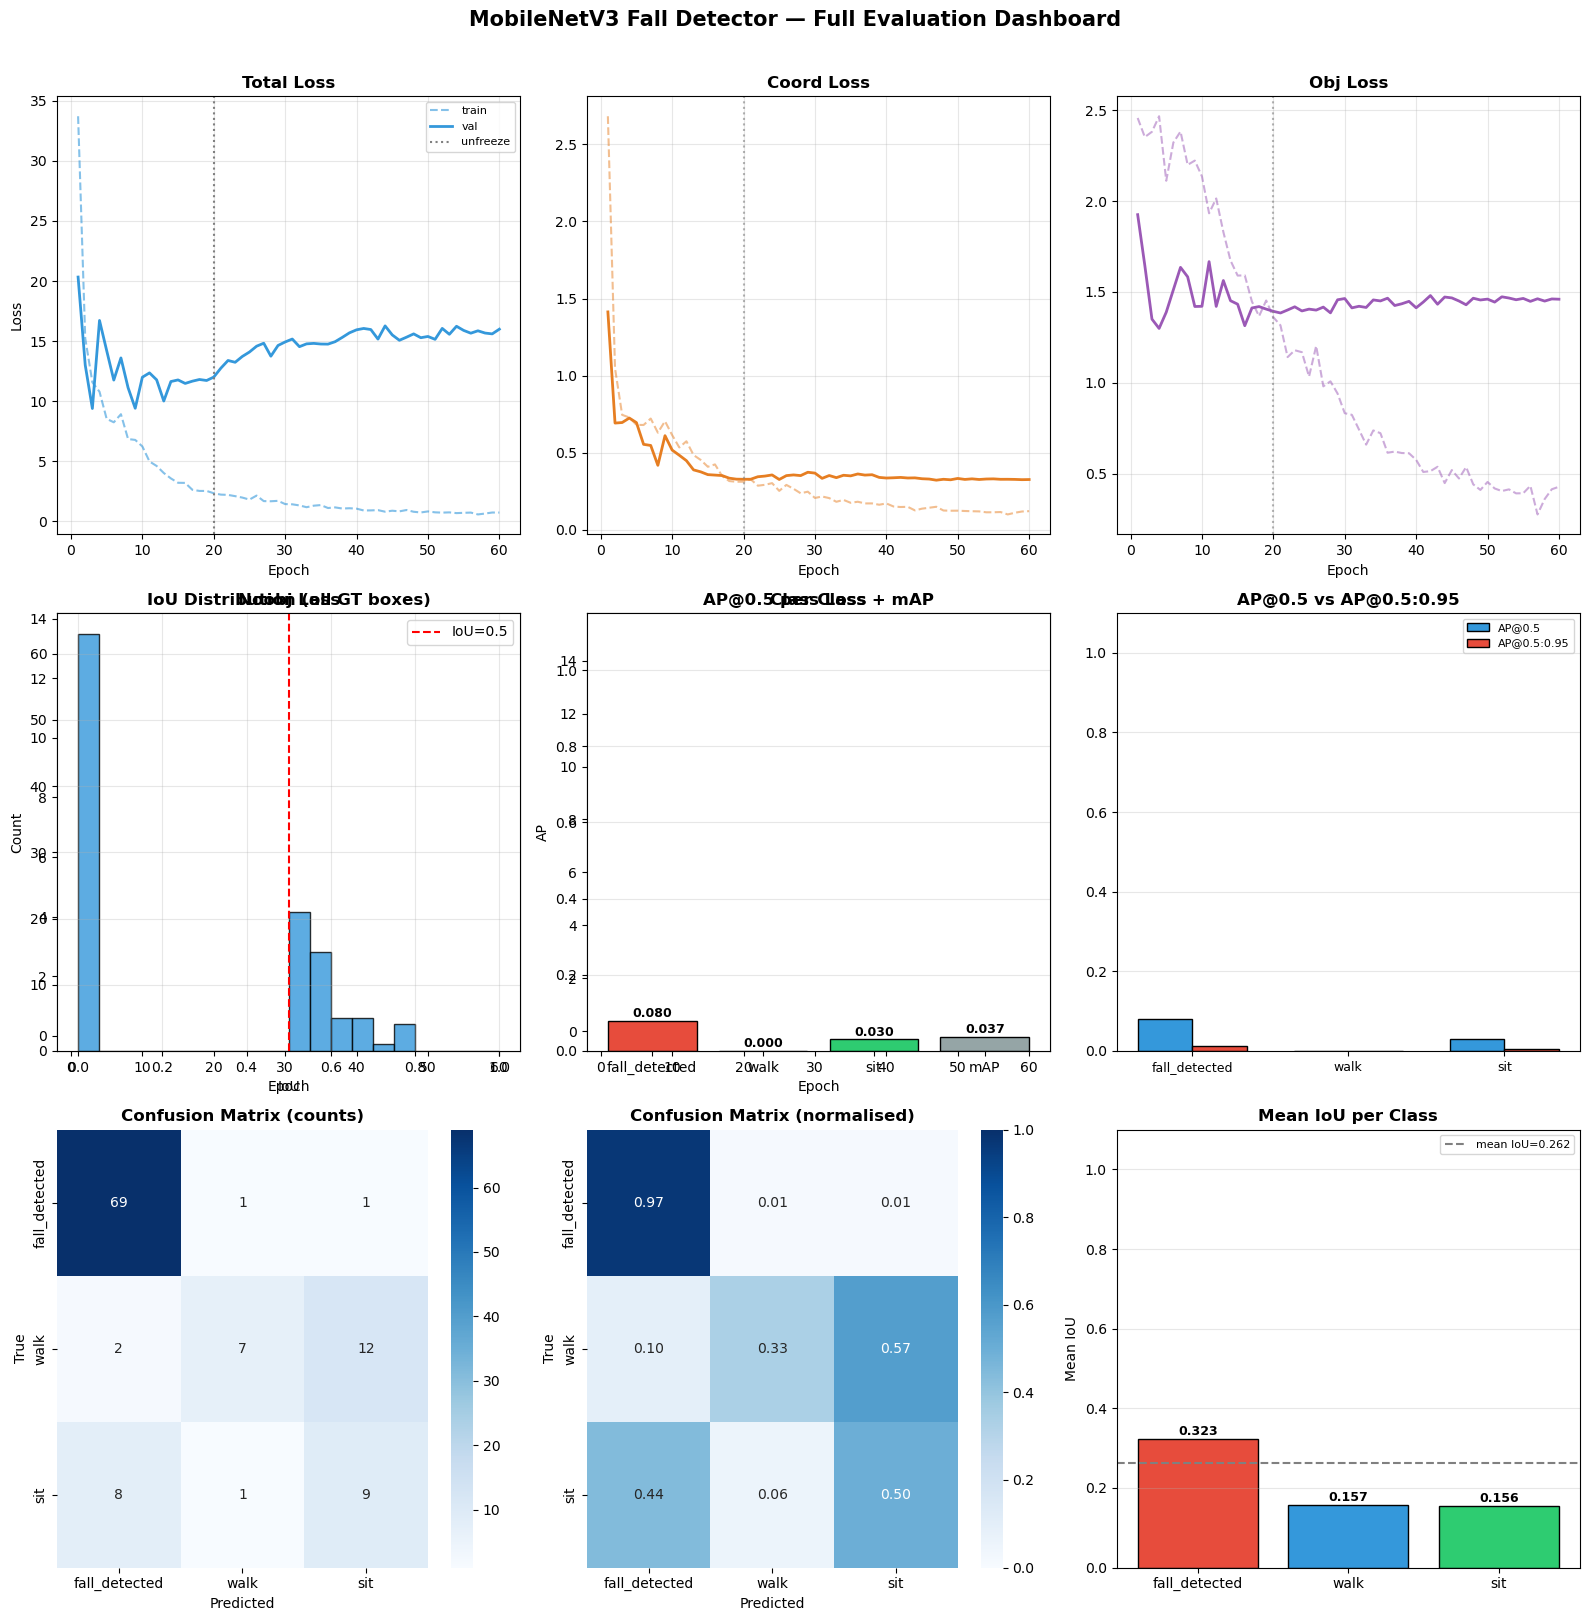


  Final Metrics Summary
  mAP@0.5        : 0.0368
  mAP@0.5:0.95   : 0.0061
  Mean IoU       : 0.2616
  Box Error Rate : 0.5526
  Class              AP@0.5      mIoU
  -----------------------------------
  fall_detected      0.0798    0.3229
  walk               0.0001    0.1571
  sit                0.0304    0.1556


In [12]:
# ── Full metrics dashboard ────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 16))
fig.suptitle('MobileNetV3 Fall Detector — Full Evaluation Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

# ── Row 1: Train/Val loss curves ─────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ep  = range(1, len(history['train_total']) + 1)
ax1.plot(ep, history['train_total'], '--', color='#3498db', alpha=0.6, label='train')
ax1.plot(ep, history['val_total'],   '-',  color='#3498db', linewidth=2, label='val')
ax1.axvline(UNFREEZE_AT, color='grey', linestyle=':', label='unfreeze')
ax1.set_title('Total Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── Row 1: Loss components ────────────────────────────────────────────────────
comp_colors = {'coord': '#e67e22', 'obj': '#9b59b6',
               'noobj': '#1abc9c', 'class': '#e74c3c'}
for i, (comp, cc) in enumerate(comp_colors.items(), start=2):
    ax = fig.add_subplot(3, 3, i)
    if f'train_{comp}' in history:
        ax.plot(ep, history[f'train_{comp}'], '--', color=cc, alpha=0.5)
        ax.plot(ep, history[f'val_{comp}'],   '-',  color=cc, linewidth=2)
    ax.axvline(UNFREEZE_AT, color='grey', linestyle=':', alpha=0.6)
    ax.set_title(f'{comp.capitalize()} Loss', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)

# ── Row 2: mAP bar chart ──────────────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
cls_labels = CLASS_NAMES + ['mAP']
ap50_vals  = [ap50[c] for c in range(NUM_CLASSES)] + [mAP50]
bar_colors = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']
bars = ax5.bar(cls_labels, ap50_vals, color=bar_colors, edgecolor='black')
for bar, v in zip(bars, ap50_vals):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax5.set_ylim(0, 1.15)
ax5.set_title('AP@0.5 per Class + mAP', fontweight='bold')
ax5.set_ylabel('AP'); ax5.grid(axis='y', alpha=0.3)

# ── Row 2: mAP@0.5 vs mAP@0.5:0.95 ─────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
x   = np.arange(NUM_CLASSES)
w   = 0.35
v50    = [ap50[c]    for c in range(NUM_CLASSES)]
v5095  = [ap5095[c]  for c in range(NUM_CLASSES)]
ax6.bar(x - w/2, v50,   w, label='AP@0.5',      color='#3498db', edgecolor='black')
ax6.bar(x + w/2, v5095, w, label='AP@0.5:0.95', color='#e74c3c', edgecolor='black')
ax6.set_xticks(x); ax6.set_xticklabels(CLASS_NAMES, fontsize=9)
ax6.set_ylim(0, 1.1)
ax6.set_title('AP@0.5 vs AP@0.5:0.95', fontweight='bold')
ax6.legend(fontsize=8); ax6.grid(axis='y', alpha=0.3)

# ── Row 2: IoU distribution histogram ────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 4)
ax7.hist(all_ious, bins=20, range=(0, 1),
         color='#3498db', edgecolor='black', alpha=0.8)
ax7.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='IoU=0.5')
ax7.set_title('IoU Distribution (all GT boxes)', fontweight='bold')
ax7.set_xlabel('IoU'); ax7.set_ylabel('Count')
ax7.legend(); ax7.grid(alpha=0.3)

# ── Row 3: Confusion matrix (counts) ─────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 7)
if y_true:
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax8, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax8.set_title('Confusion Matrix (counts)', fontweight='bold')
    ax8.set_xlabel('Predicted'); ax8.set_ylabel('True')
else:
    ax8.text(0.5, 0.5, 'No matched pairs\n(lower conf_thresh)',
             ha='center', va='center', transform=ax8.transAxes)

# ── Row 3: Confusion matrix (normalised) ─────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 8)
if y_true:
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax9, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1)
    ax9.set_title('Confusion Matrix (normalised)', fontweight='bold')
    ax9.set_xlabel('Predicted'); ax9.set_ylabel('True')

# ── Row 3: Per-class IoU bar ──────────────────────────────────────────────────
ax10 = fig.add_subplot(3, 3, 9)
iou_vals = [cls_iou.get(c, 0.0) for c in range(NUM_CLASSES)]
bars = ax10.bar(CLASS_NAMES, iou_vals,
                color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')
for bar, v in zip(bars, iou_vals):
    ax10.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.01,
              f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax10.axhline(mean_iou, color='grey', linestyle='--',
              label=f'mean IoU={mean_iou:.3f}')
ax10.set_ylim(0, 1.1)
ax10.set_title('Mean IoU per Class', fontweight='bold')
ax10.set_ylabel('Mean IoU')
ax10.legend(fontsize=8); ax10.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fall_detector_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"="*50}')
print(f'  Final Metrics Summary')
print(f'{"="*50}')
print(f'  mAP@0.5        : {mAP50:.4f}')
print(f'  mAP@0.5:0.95   : {mAP5095:.4f}')
print(f'  Mean IoU       : {mean_iou:.4f}')
print(f'  Box Error Rate : {box_err:.4f}')
print(f'  {"Class":<15}  {"AP@0.5":>8}  {"mIoU":>8}')
print(f'  {"-"*35}')
for c, name in enumerate(CLASS_NAMES):
    print(f'  {name:<15}  {ap50[c]:>8.4f}  {cls_iou.get(c,0):>8.4f}')
print(f'{"="*50}')

## 9. Qualitative Predictions

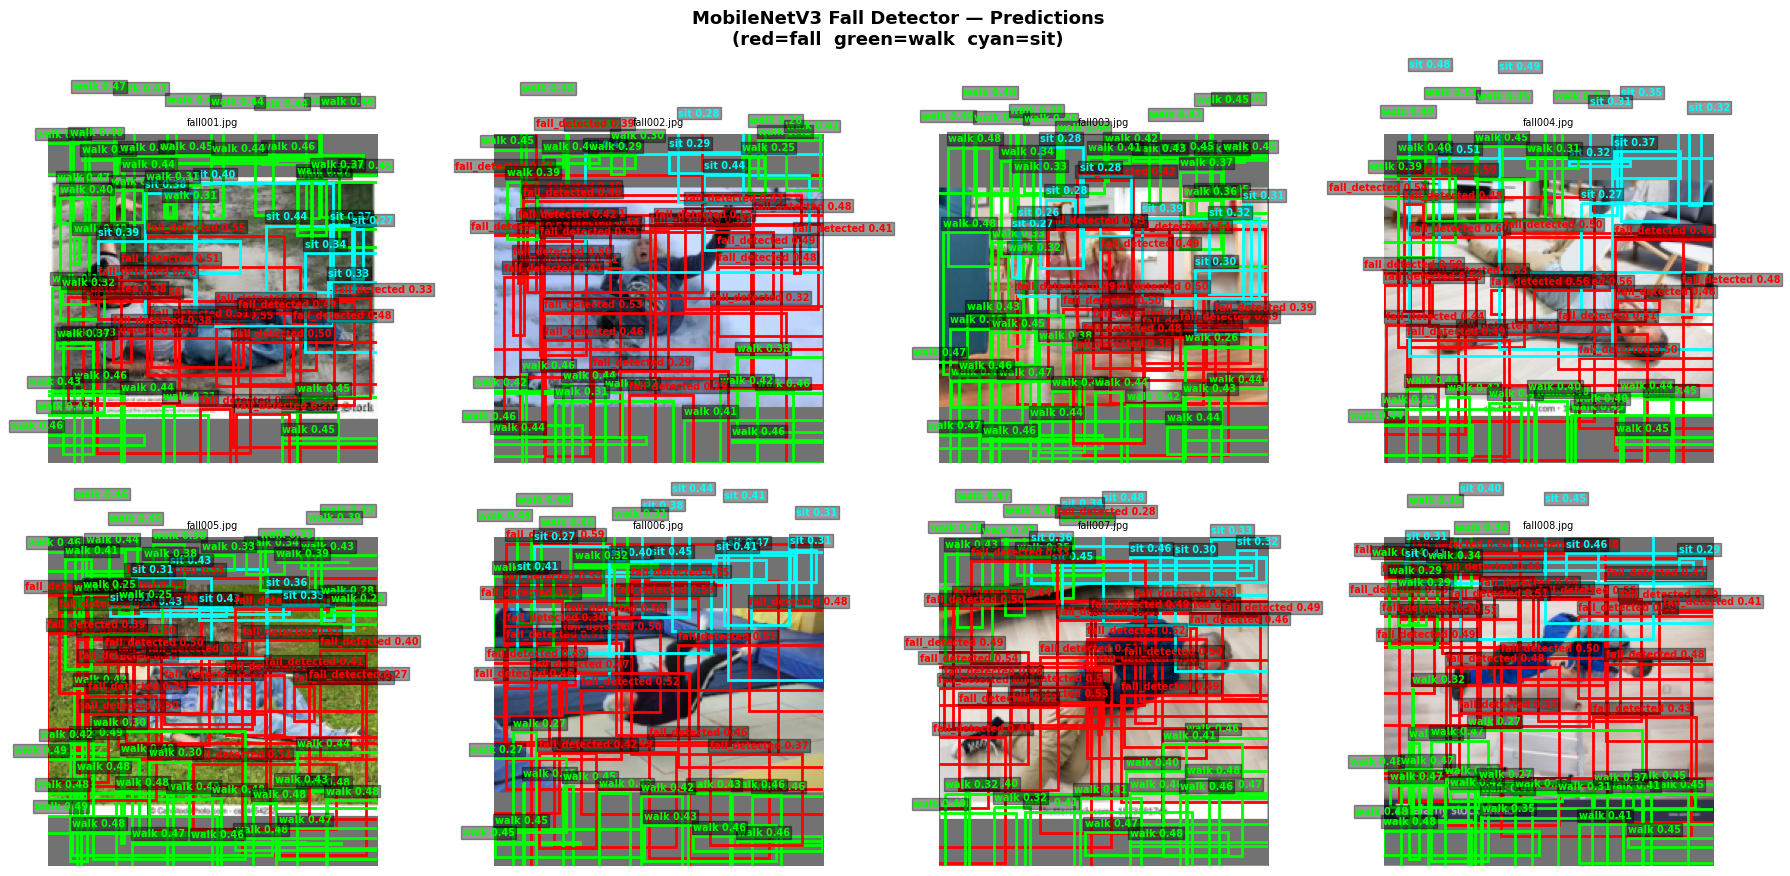

In [13]:
BOX_COLORS = {'fall_detected': 'red', 'walk': 'lime', 'sit': 'cyan'}

test_imgs = list((IMG_DIR / 'val').glob('*.jpg'))[:8]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

model.eval()
for ax, img_path in zip(axes, test_imgs):
    img_pil = Image.open(img_path).convert('RGB')
    W, H    = img_pil.size
    tensor  = INFER_TF(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(tensor)[0]

    dets = decode_predictions(output, S=S, B=B, C=NUM_CLASSES,
                               conf_thresh=0.25, nms_thresh=0.35)

    # Show letterboxed image (what model sees)
    lb_img = LetterboxResize(IMG_SIZE)(img_pil)
    lW, lH = lb_img.size
    ax.imshow(lb_img)

    for det in dets:
        x1, y1, x2, y2 = det['box']
        cls_name = CLASS_NAMES[det['class']]
        color    = BOX_COLORS.get(cls_name, 'white')
        rect = patches.Rectangle(
            (x1*lW, y1*lH), (x2-x1)*lW, (y2-y1)*lH,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1*lW, y1*lH - 4,
                f"{cls_name} {det['score']:.2f}",
                color=color, fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, pad=1))

    ax.set_title(img_path.name, fontsize=7)
    ax.axis('off')

plt.suptitle('MobileNetV3 Fall Detector — Predictions\n'
             '(red=fall  green=walk  cyan=sit)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fall_detector_predictions.png', dpi=150, bbox_inches='tight')
plt.show()